# Titanic - Machine Learning from Disaster

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

print(train.shape, test.shape)
train.head()

(891, 12) (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 欠損値確認

In [2]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## 探索的データ分析

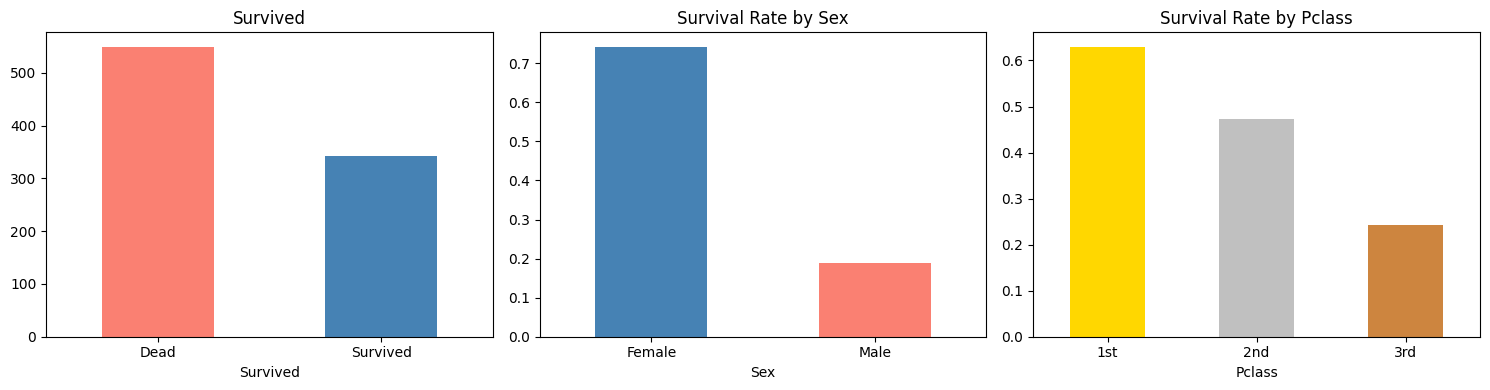

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 生存率
train['Survived'].value_counts().plot(kind='bar', ax=axes[0], color=['salmon', 'steelblue'])
axes[0].set_title('Survived')
axes[0].set_xticklabels(['Dead', 'Survived'], rotation=0)

# 性別と生存率
train.groupby('Sex')['Survived'].mean().plot(kind='bar', ax=axes[1], color=['steelblue', 'salmon'])
axes[1].set_title('Survival Rate by Sex')
axes[1].set_xticklabels(['Female', 'Male'], rotation=0)

# 客室クラスと生存率
train.groupby('Pclass')['Survived'].mean().plot(kind='bar', ax=axes[2], color=['gold', 'silver', 'peru'])
axes[2].set_title('Survival Rate by Pclass')
axes[2].set_xticklabels(['1st', '2nd', '3rd'], rotation=0)

plt.tight_layout()
plt.show()

## 特徴量エンジニアリング

In [4]:
def preprocess(df):
    df = df.copy()
    # 性別を数値に
    df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
    # 年齢の欠損を中央値で補完
    df['Age'] = df['Age'].fillna(df['Age'].median())
    # 乗船港の欠損を最頻値で補完 → 数値化
    df['Embarked'] = df['Embarked'].fillna('S').map({'S': 0, 'C': 1, 'Q': 2})
    # 家族数
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
    # 運賃の欠損補完
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())
    return df

train = preprocess(train)
test = preprocess(test)

features = ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize', 'IsAlone']
X = train[features]
y = train['Survived']
X_test = test[features]

print('特徴量:', features)
X.head()

特徴量: ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize', 'IsAlone']


,Pclass,Sex,Age,Fare,Embarked,FamilySize,IsAlone
0,3,0,22.0,7.2500,0,2,0
1,1,1,38.0,71.2833,1,2,0
2,3,1,26.0,7.9250,0,1,1
3,1,1,35.0,53.1000,0,2,0
4,3,0,35.0,8.0500,0,1,1


## モデル学習 (Random Forest)

CV Accuracy: 0.8104 ± 0.0214


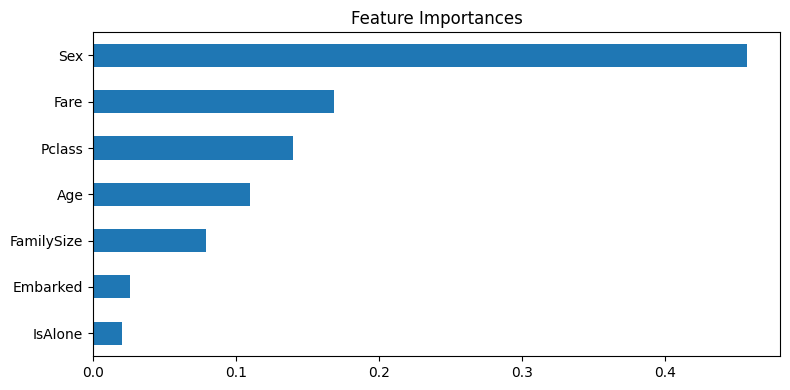

In [5]:
model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print(f'CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

model.fit(X, y)

# 特徴量重要度
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)
importances.plot(kind='barh', figsize=(8, 4), title='Feature Importances')
plt.tight_layout()
plt.show()

## 予測 & 提出ファイル作成

In [6]:
predictions = model.predict(X_test)
submission = pd.DataFrame({'PassengerId': test['PassengerId'], 'Survived': predictions})
submission.to_csv('submission.csv', index=False)
print('submission.csv を保存しました')
submission.head(10)

submission.csv を保存しました


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
5,897,0
6,898,1
7,899,0
8,900,1
9,901,0


## Kaggle に提出

In [7]:
import subprocess
import sys
from pathlib import Path

kaggle_bin = Path(sys.executable).parent / 'kaggle'

result = subprocess.run(
    [str(kaggle_bin), 'competitions', 'submit', '-c', 'titanic', '-f', 'submission.csv', '-m', 'Random Forest baseline'],
    capture_output=True, text=True
)
print(result.stdout)
print(result.stderr)

Successfully submitted to Titanic - Machine Learning from Disaster

  0%|          | 0.00/2.77k [00:00<?, ?B/s]
100%|██████████| 2.77k/2.77k [00:00<00:00, 18.3kB/s]
100%|██████████| 2.77k/2.77k [00:00<00:00, 2.89kB/s]

